**First, we will import the required libraries that we will use throughout the project.**

In [2]:
import pandas as pd
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from matplotlib import pyplot as plt
from textblob import TextBlob
from sklearn.metrics import confusion_matrix, classification_report

**Load the IMDb Movie Reviews Dataset.**

In [5]:
data = pd.read_csv('IMDB_Dataset.csv')

### **EDA (Exploratory Data Analysis)**

**Next, we will do some EDA on the loaded dataset.**

In [8]:
data.head(10)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
9,If you like original gut wrenching laughter yo...,positive


In [10]:
data.shape

(50000, 2)

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [14]:
data.isna().sum()

review       0
sentiment    0
dtype: int64

In [16]:
data['sentiment'].unique()

array(['positive', 'negative'], dtype=object)

In [18]:
data['sentiment'].value_counts()

positive    25000
negative    25000
Name: sentiment, dtype: int64

<Axes: xlabel='sentiment', ylabel='count'>

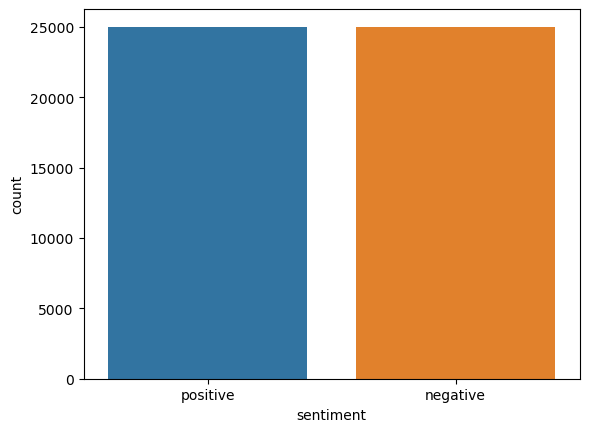

In [20]:
sns.countplot(data=data, x=data['sentiment'])

**By checking the dataset, we can see that it has two columns: 'review' and 'sentiment'. There are 50000 movie reviews in total, of which all are non-null. Furthermore, the classes (positive and negative) are perfectly balanced, since each one of them has 25000 values.**

### **Clean the text data**

**For the next step, we will create a function that cleans the inserted text and apply it to all the reviews ('review' column). First we will download a list of english stopwords and load it. Inside the function, we will convert the inserted text to lowercase, then use RegEx to remove punctuation symbols, special characters and numbers and also remove extra whitespaces that might exist inside the text. Finally, we will use list comprehension to tokenize the text into words, remove the stopwords from the list of tokens and then combine the remaining tokens into a single string.** 

In [11]:
nltk.download('stopwords')

stop = stopwords.words('english')

def text_cleaner(text):
    text = text.lower() 
    text = re.sub(r'[^A-Za-z\s]', '', text)  
    text = re.sub(r'\s+', ' ', text).strip()  

    output_text = " ".join([word for word in word_tokenize(text) if word not in stop])
    
    return output_text

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lefos\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
data['cleaned_review'] = data['review'].apply(text_cleaner)

In [15]:
data['review'][55]

"As someone has already mentioned on this board, it's very difficult to make a fake documentary. It requires tremendous skill, pacing, patience, directorial 'distance,' a plausible premise, a narrative 'flow,' and REALLY believable acting (aka GREAT acting). <br /><br />Such is not the case with 'Love Machine'. It starts to show its faux hand about the 20-minute mark (with 60 minutes left to watch), and the viewer starts to realize that he or she is being taken in. It's downhill from there.<br /><br />Director Gordon Eriksen simply peaked too soon. But to be fair to Eriksen, his problems started early: as he explains in the extras, he began wanting to do a REAL doc, couldn't get funding, and settled for a cheaper way of making his film.<br /><br />The premise -- people who have secret lives by posting themselves on a porn website -- was perhaps more interesting in 1997-98, when the film was made. Eriksen does a lot of tricky stuff -- a pushy 'host,' hand-held cameras, zooms, grainy bla

In [17]:
data['cleaned_review'][55]

'someone already mentioned board difficult make fake documentary requires tremendous skill pacing patience directorial distance plausible premise narrative flow really believable acting aka great acting br br case love machine starts show faux hand minute mark minutes left watch viewer starts realize taken downhill therebr br director gordon eriksen simply peaked soon fair eriksen problems started early explains extras began wanting real doc couldnt get funding settled cheaper way making filmbr br premise people secret lives posting porn website perhaps interesting film made eriksen lot tricky stuff pushy host handheld cameras zooms grainy blacks whites guess elicit sense authenticity doesnt work film confusing forced ultimately brings believability actors pretty awful dialogue'

**Now that the reviews are cleaned, we will generate two wordclouds for the positive and negative sentiments respectively. To get the positive and negative reviews from the dataset we will extract all reviews from the 'cleaned_review' column where the sentiments from the 'sentiment' column are positive and negative respectively. Then we will combine all the positive reviews into a single string and do the same with the negative reviews, since Wordcloud requires a single string as input. Some common words such as 'film', 'movie', 'character', 'br' (html line break) that can appear in both sentiments will be excluded.**

In [20]:
positive_reviews = " ".join(data[data['sentiment'] == 'positive']['cleaned_review'])
negative_reviews = " ".join(data[data['sentiment'] == 'negative']['cleaned_review'])

positive_wc = WordCloud(width=800, height=400, colormap='Greens', stopwords=['film', 'movie', 'character', 'br']).generate(positive_reviews)
negative_wc = WordCloud(width=800, height=400, colormap='Reds', stopwords=['film', 'movie', 'character', 'br']).generate(negative_reviews)

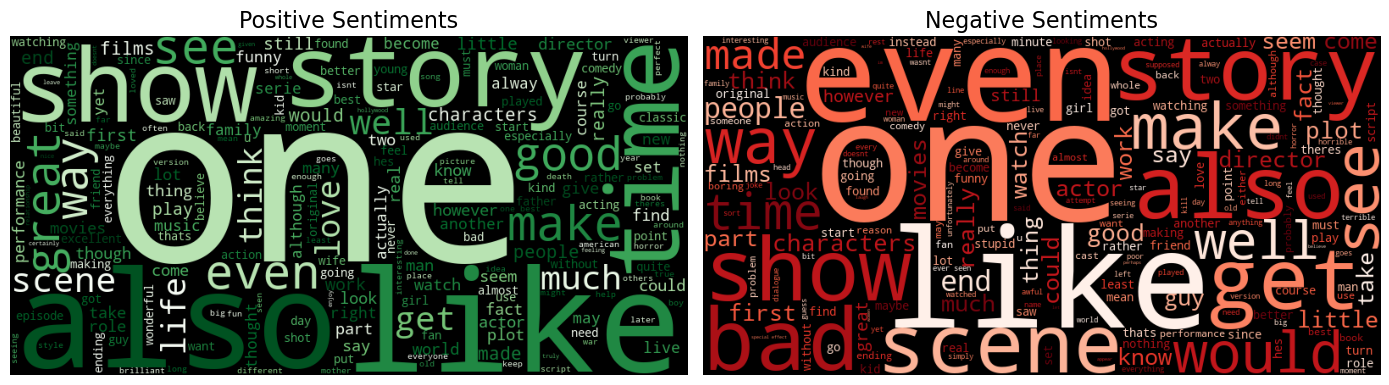

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(positive_wc)
axes[0].axis('off')
axes[0].set_title('Positive Sentiments', fontsize=16)

axes[1].imshow(negative_wc)
axes[1].axis('off')
axes[1].set_title('Negative Sentiments', fontsize=16)

plt.tight_layout()
plt.show()

**In the positive wordcloud we can easily highlight words such as 'like', 'good', 'great', 'love'. In the negative wordcloud though, it is not as easy to distinguish words that represent the negative sentiment, with the word 'bad' possibly being the only exception. On the contrary, we can locate words that belong in the negative wordcloud but could be misinterpreted as positive like: 'well', 'good', 'like' etc. This issue may cause a problem with the sentiment analysis analyzed in the next two sections.**

### **Sentiment Analysis with TextBlob**

**In this section we will do a sentiment analysis using the TextBlob library. The sentiments will be classified as positive or negative based on the polarity score.**

**The following function returns positive if polarity score >= 0 and negative if polarity score < 0. We create a new column 'predicted_sentiment_textblob' by applying the function to the 'cleaned_review' column.**

In [29]:
def classify_polarity_textblob(review):
    review_pol = TextBlob(review).sentiment.polarity
    if review_pol >= 0:
        return 'positive'
    else:
        return 'negative'

In [31]:
data['predicted_sentiment_textblob'] = data['cleaned_review'].apply(classify_polarity_textblob)

In [33]:
data.head(10)

,review,sentiment,cleaned_review,predicted_sentiment_textblob
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching oz episode yo...,positive
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...,positive
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...,positive
3,Basically there's a family where a little boy ...,negative,basically theres family little boy jake thinks...,positive
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...,positive
5,"Probably my all-time favorite movie, a story o...",positive,probably alltime favorite movie story selfless...,positive
6,I sure would like to see a resurrection of a u...,positive,sure would like see resurrection dated seahunt...,positive
7,"This show was an amazing, fresh & innovative i...",negative,show amazing fresh innovative idea first aired...,positive
8,Encouraged by the positive comments about this...,negative,encouraged positive comments film looking forw...,negative
9,If you like original gut wrenching laughter yo...,positive,like original gut wrenching laughter like movi...,positive


In [35]:
print(f"Predicted positive and negative values\n{data['predicted_sentiment_textblob'].value_counts()}")
print(f"Percentage of predicted positive and negative values\n{data['predicted_sentiment_textblob'].value_counts()*100/50000}")

Predicted positive and negative values
positive    36679
negative    13321
Name: predicted_sentiment_textblob, dtype: int64
Percentage of predicted positive and negative values
positive    73.358
negative    26.642
Name: predicted_sentiment_textblob, dtype: float64


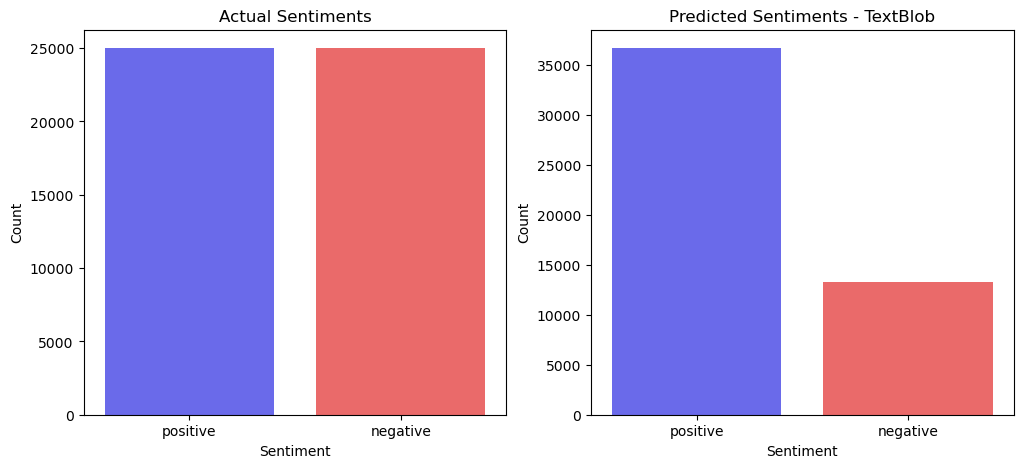

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 

sns.countplot(x=data['sentiment'], ax=axes[0], palette='seismic', order=['positive', 'negative'])
axes[0].set_title('Actual Sentiments')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')

sns.countplot(x=data['predicted_sentiment_textblob'], ax=axes[1], palette='seismic', order=['positive', 'negative'])
axes[1].set_title('Predicted Sentiments - TextBlob')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')

plt.show()

**By looking at the results, TextBlob interprets approximately 73% of the reviews as positive and 27% as negative. The wordclouds shown earlier helped us suspect that this problem would occur, since there are not many "negative" words that can help TextBlob interpret a review as negative. On the contrary, some "positive" words are found in the actual negative sentiments, which might be the reason why TextBlob interprets most reviews as positive.**

In [40]:
print(classification_report(y_true=data['sentiment'], y_pred=data['predicted_sentiment_textblob']))

              precision    recall  f1-score   support

    negative       0.88      0.47      0.61     25000
    positive       0.64      0.93      0.76     25000

    accuracy                           0.70     50000
   macro avg       0.76      0.70      0.68     50000
weighted avg       0.76      0.70      0.68     50000



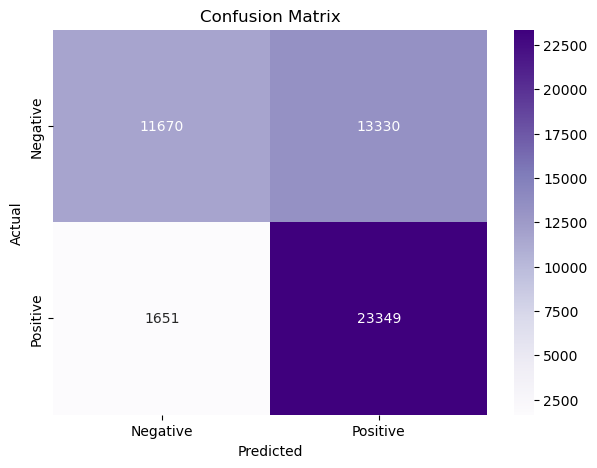

In [42]:
cm_txtblb = confusion_matrix(data['sentiment'], data['predicted_sentiment_textblob'])
plt.figure(figsize=(7,5))
sns.heatmap(cm_txtblb, annot=True, fmt='d', cmap='Purples', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**In the above cells, we print the classification report that shows the accuracy (0.70), precision (0.76), recall (0.70) and f1-score (0.68). We also visualize the confusion matrix which shows that 11670 negative reviews are correctly classified as negative (TN), 13330 negative reviews are incorrectly classified as positive (FP), 1651 positive reviews are incorrectly classified as negative (FN) and 23349 positive reviews are correctly classified as positive (TP).**

### **Sentiment Analysis with VADER**

**In the last section we will do a sentiment analysis using the VADER library. The sentiments will be classified as positive or negative based on VADER's compound score.
VADER is a lexicon tool so we will first download it and then create a SentimentIntensityAnalyzer object.**

**The following function returns positive if compound score >= 0 and negative if compound score < 0. We create a new column 'predicted_sentiment_vader' by applying the function to the 'cleaned_review' column.**

In [47]:
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def classify_polarity_vader(review):
    review_comp_score = sia.polarity_scores(review)['compound']
    if review_comp_score >= 0:
        return 'positive'
    else: 
        return 'negative'

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\lefos\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [49]:
data['predicted_sentiment_vader'] = data['cleaned_review'].apply(classify_polarity_vader)

In [51]:
data.head(10)

,review,sentiment,cleaned_review,predicted_sentiment_textblob,predicted_sentiment_vader
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching oz episode yo...,positive,negative
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...,positive,positive
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...,positive,positive
3,Basically there's a family where a little boy ...,negative,basically theres family little boy jake thinks...,positive,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...,positive,positive
5,"Probably my all-time favorite movie, a story o...",positive,probably alltime favorite movie story selfless...,positive,positive
6,I sure would like to see a resurrection of a u...,positive,sure would like see resurrection dated seahunt...,positive,positive
7,"This show was an amazing, fresh & innovative i...",negative,show amazing fresh innovative idea first aired...,positive,positive
8,Encouraged by the positive comments about this...,negative,encouraged positive comments film looking forw...,negative,negative
9,If you like original gut wrenching laughter yo...,positive,like original gut wrenching laughter like movi...,positive,positive


In [53]:
print(f"Predicted positive and negative values\n{data['predicted_sentiment_vader'].value_counts()}")
print(f"Percentage of predicted positive and negative values\n{data['predicted_sentiment_vader'].value_counts()*100/50000}")

Predicted positive and negative values
positive    34324
negative    15676
Name: predicted_sentiment_vader, dtype: int64
Percentage of predicted positive and negative values
positive    68.648
negative    31.352
Name: predicted_sentiment_vader, dtype: float64


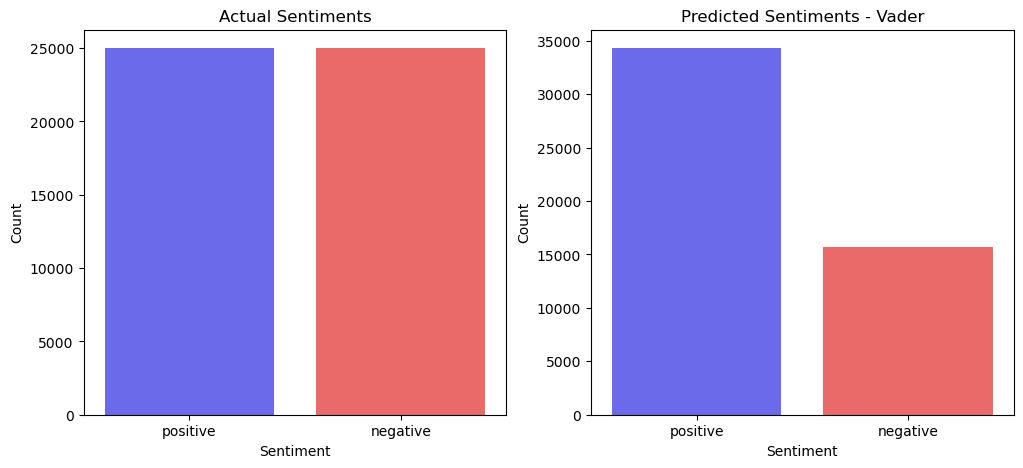

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 

sns.countplot(x=data['sentiment'], ax=axes[0], palette='seismic', order=['positive', 'negative'])
axes[0].set_title('Actual Sentiments')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')

sns.countplot(x=data['predicted_sentiment_vader'], ax=axes[1], palette='seismic', order=['positive', 'negative'])
axes[1].set_title('Predicted Sentiments - Vader')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')

plt.show()

**By looking at the results, VADER interprets approximately 69% of the reviews as positive and 31% as negative, facing the same problem as TextBlob.**

In [58]:
print(classification_report(y_true=data['sentiment'], y_pred=data['predicted_sentiment_vader']))

              precision    recall  f1-score   support

    negative       0.78      0.49      0.60     25000
    positive       0.63      0.86      0.73     25000

    accuracy                           0.68     50000
   macro avg       0.70      0.68      0.66     50000
weighted avg       0.70      0.68      0.66     50000



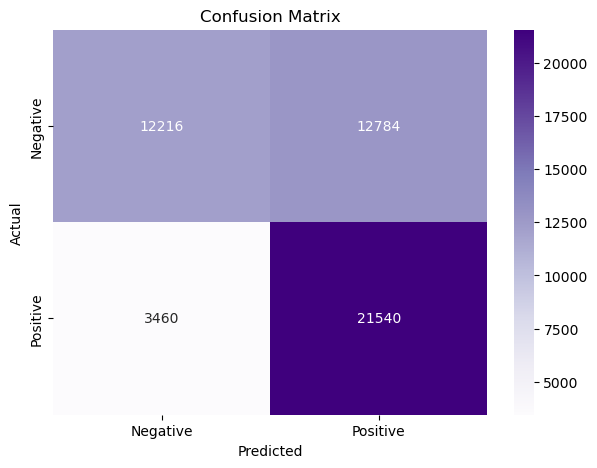

In [60]:
cm_vader = confusion_matrix(data['sentiment'], data['predicted_sentiment_vader'])
plt.figure(figsize=(7,5))
sns.heatmap(cm_vader, annot=True, fmt='d', cmap='Purples', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**In the above cells, we print the classification report that shows the accuracy (0.68), precision (0.70), recall (0.68) and f1-score (0.66). We also visualize the confusion matrix which shows that 12216 negative reviews are correctly classified as negative (TN), 12784 negative reviews are incorrectly classified as positive (FP), 3460 positive reviews are incorrectly classified as negative (FN) and 21540 positive reviews are correctly classified as positive (TP).**

**Overall, by comparing the metrics, we can see that TextBlob slightly outperforms VADER. Regarding the negative sentiments both models have difficulty identifying them comprehensively (low recall for negatives). TextBlob seems to favor precision (better at avoiding incorrect classifications) while Vader provides a slightly more balanced performance.**